<div style="background: linear-gradient(135deg, #1a237e, #283593); padding: 40px; border-radius: 12px; text-align: center; color: white; margin-bottom: 20px;">
  <h1 style="font-size: 2.4em; margin-bottom: 10px;">📊 Análisis de Correspondencia Múltiple (ACM)</h1>
  <h2 style="font-size: 1.4em; font-weight: 300;">Cómo los hábitos de sueño y rendimiento definen perfiles estudiantiles</h2>
  <p style="margin-top: 15px; font-size: 1em; opacity: 0.85;">Probabilidad y Estadística I &nbsp;|&nbsp; Presentación Académica</p>
</div>

---
# 1. Introducción

## ¿Qué es el Análisis de Correspondencia Múltiple (ACM)?

El **Análisis de Correspondencia Múltiple (ACM)** es una técnica estadística multivariada de reducción de la dimensionalidad, diseñada específicamente para trabajar con **variables categóricas** (nominales u ordinales).

Puede entenderse como la **extensión del Análisis de Componentes Principales (PCA) al mundo de los datos cualitativos**: en lugar de correlaciones entre variables numéricas, analiza las **asociaciones entre categorías** de distintas variables.

El ACM transforma tablas de respuestas de encuestas en un **mapa visual de baja dimensión** donde:
- Categorías con perfiles similares aparecen **cerca** en el plano.
- Categorías con perfiles opuestos aparecen **lejos** entre sí.
- Los individuos con patrones de respuesta similares se agrupan en las mismas regiones.

---

## ¿Qué problema resuelve?

Cuando se tienen múltiples variables categóricas (como en encuestas), **no es posible aplicar directamente** técnicas clásicas (correlación de Pearson, regresión lineal, PCA) porque estas asumen datos numéricos continuos. El ACM resuelve este problema mediante:

| Problema | Solución del ACM |
|----------|------------------|
| Variables no numéricas | Transforma categorías en coordenadas numéricas |
| Muchas variables difíciles de visualizar | Reduce a 2 o 3 dimensiones interpretables |
| Relaciones complejas entre categorías | Las representa como distancias geométricas |
| Dificultad para identificar perfiles | Agrupa individuos con comportamientos similares |

---

## Objetivos del ACM

1. **Representar y resumir** la información contenida en variables categóricas.
2. **Identificar asociaciones** entre categorías de distintas variables.
3. **Caracterizar perfiles** de individuos según sus respuestas.
4. **Reducir la dimensionalidad**: pasar de muchas variables a pocos factores interpretables.
5. **Construir variables sintéticas continuas (latentes)** que resuman los patrones de variación.
6. **Visualizar** datos complejos en mapas perceptuales (biplots).

---

## El problema con nuestros datos: variables categóricas

Imagina que encuestas a **64 estudiantes** sobre sus hábitos de sueño y rendimiento académico.  
Las respuestas **no son números**: son categorías como `"A veces"`, `"Frecuentemente"`, `"Si, mucho"`.

| Técnica | ¿Cuándo usarla? | ¿Por qué no aquí? |
|---------|----------------|--------------------|
| Correlación de Pearson | Variables numéricas continuas | Nuestras variables son categóricas |
| Regresión Lineal | Variable respuesta numérica | No hay números |
| PCA | Variables numéricas | No funciona con categorías directamente |
| **ACM ✅** | **Múltiples variables categóricas** | **¡Exactamente nuestro caso!** |

```
Encuesta (64 estudiantes × 16 variables categóricas)  →  ACM  →  Mapa 2D de perfiles
       [difícil de interpretar directamente]                      [fácil de visualizar]
```

---

## 🔑 Preguntas Guía — Sección 1

> **Checklist conceptual para expositores:**
> 
> 1. ¿Qué son las variables latentes y por qué son importantes en el ACM?
> 2. ¿Qué tipo de datos analiza el ACM y por qué no se pueden analizar directamente?
> 3. ¿Qué significa reducir la dimensionalidad en este contexto?
> 4. ¿Qué diferencia hay entre ACM y otras técnicas como el Análisis de Correspondencias Simple?
> 5. ¿Qué se gana al transformar variables categóricas en variables numéricas?

---
# 2. Contexto de los Datos

## Descripción de la base de datos

Este estudio trabaja con un conjunto de datos recolectados por estudiantes de la asignatura **Probabilidad y Estadística I**.  
A partir de una muestra de **64 estudiantes**, se tomaron datos relacionados con hábitos de sueño, rendimiento académico y características sociodemográficas.

---

## Variables del dataset

| Variable | Descripción | Tipo |
|----------|-------------|------|
| `SEMESTRE` | Semestre académico del estudiante | Ordinal |
| `GENERO` | Sexo del estudiante | Nominal |
| `CARRERA` | Programa académico principal | Nominal |
| `DOBLECARRERA` | Si cursa doble programa (Sí/No) | Nominal binaria |
| `HORAS` | Promedio de horas de sueño | Ordinal |
| `SLEEP` | Frecuencia de sueño adecuado | Ordinal |
| `FACTORES` | Razones que afectan el descanso | Nominal |
| `CONCENTRACION` | Nivel de concentración percibido | Ordinal |
| `DESEMPENO` | Autoevaluación del rendimiento académico | Ordinal |
| `PUNTUALIDAD` | Nivel de puntualidad en actividades | Ordinal |
| `FATIGA` | Nivel de cansancio reportado | Ordinal |
| `BECA` | Si cuenta con beca (Sí/No) | Nominal binaria |
| `RETIRO` | Si ha retirado materias (Sí/No) | Nominal binaria |
| `CREDITOS` | Créditos matriculados en el semestre | Ordinal |
| `CALIDAD` | Percepción de calidad del sueño | Ordinal |
| `ACTIVIDADES` | Actividades extracurriculares | Nominal |

---

## 🔑 Preguntas Guía — Sección 2

> **Checklist conceptual para expositores:**
> 
> 1. ¿Qué tipo de variables contiene la base de datos?
> 2. ¿Por qué es importante que las variables sean categóricas en el ACM?
> 3. ¿Cómo se interpretan los individuos dentro del análisis?
> 4. ¿Qué papel juegan las categorías dentro del modelo?
> 5. ¿Qué tipo de problemas reales puede representar esta base de datos?

In [1]:
# ─── Importación de librerías ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from matplotlib.gridspec import GridSpec
from collections import Counter

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 11
})

print("✅ Librerías importadas correctamente")

Matplotlib is building the font cache; this may take a moment.


✅ Librerías importadas correctamente


In [3]:
# ─── Carga del dataset ───────────────────────────────────────────────────────
# Reemplaza la ruta con la ubicación de tu archivo
df_raw = pd.read_excel('Base_de_datos_organizada_proyecto__2_.xlsx')

print(f"📐 Dimensiones del dataset: {df_raw.shape[0]} estudiantes × {df_raw.shape[1]} variables")
print(f"\n📋 Variables disponibles:")
for i, col in enumerate(df_raw.columns, 1):
    n_cats = df_raw[col].nunique()
    print(f"  {i:2d}. {col:<20} → {n_cats} categorías")

📐 Dimensiones del dataset: 64 estudiantes × 16 variables

📋 Variables disponibles:
   1. SEMESTRE             → 8 categorías
   2. GENERO               → 2 categorías
   3. CARRERA              → 21 categorías
   4. DOBLECARRERA         → 2 categorías
   5. HORAS                → 3 categorías
   6. SLEEP                → 4 categorías
   7. FACTORES             → 6 categorías
   8. CONCENTRACION        → 4 categorías
   9. DESEMPENO            → 4 categorías
  10. PUNTUALIDAD          → 3 categorías
  11. FATIGA               → 3 categorías
  12. BECA                 → 2 categorías
  13. RETIRO               → 2 categorías
  14. CREDITOS             → 4 categorías
  15. CALIDAD              → 4 categorías
  16. ACTIVIDADES          → 7 categorías


In [4]:
# ─── Vista general del dataset ───────────────────────────────────────────────
print("Vista de las primeras 5 filas:")
df_raw.head()

Vista de las primeras 5 filas:


,SEMESTRE,GENERO,CARRERA,DOBLECARRERA,HORAS,SLEEP,FACTORES,CONCENTRACION,DESEMPENO,PUNTUALIDAD,FATIGA,BECA,RETIRO,CREDITOS,CALIDAD,ACTIVIDADES
0,2,Femenino,Administration de negocios internacionales,No,Entre 4 y 6 horas,Frecuentemente,Estrés académico,"Si, en la mayoría de ocasiones","Si, mucho",Rara vez,"Si, pero nunca lo considere",No,No,20,"Si, de forma constante",Deportes
1,4,Femenino,Administración de mercadeo y logística interna...,No,Entre 6 y 8 horas,Casi nunca,Ansiedad o preocupaciones personales,Solo en días de exámenes o entregas importantes,"Si, mucho","Si, varias veces","Si, lo he pensado seriamente",No,No,20,"No afecta mucho, lo manejo bien",Deportes
2,4,Masculino,Administración de mercadeo y logística interna...,No,Entre 6 y 8 horas,A veces,Malos hábitos de horario (acostarse tarde),"Si, siempre","Si, mucho",Nunca,"No, nunca lo he pensado",No,No,10,"Si, de forma constante",Trabajo
3,4,Femenino,Administración de mercadeo y logística interna...,No,Entre 4 y 6 horas,A veces,Malos hábitos de horario (acostarse tarde),"Si, en la mayoría de ocasiones","Si, mucho",Nunca,"No, nunca lo he pensado",No,No,Más de 20,Solo en semana de parciales y entregas,Deportes
4,5,Femenino,Ingeniería Química,No,Entre 6 y 8 horas,Casi nunca,Uso excesivo de celular o dispositivos electró...,Solo en días de exámenes o entregas importantes,Si pero de manera leve,"Si, varias veces","No, nunca lo he pensado",No,No,20,Solo en semana de parciales y entregas,Deportes


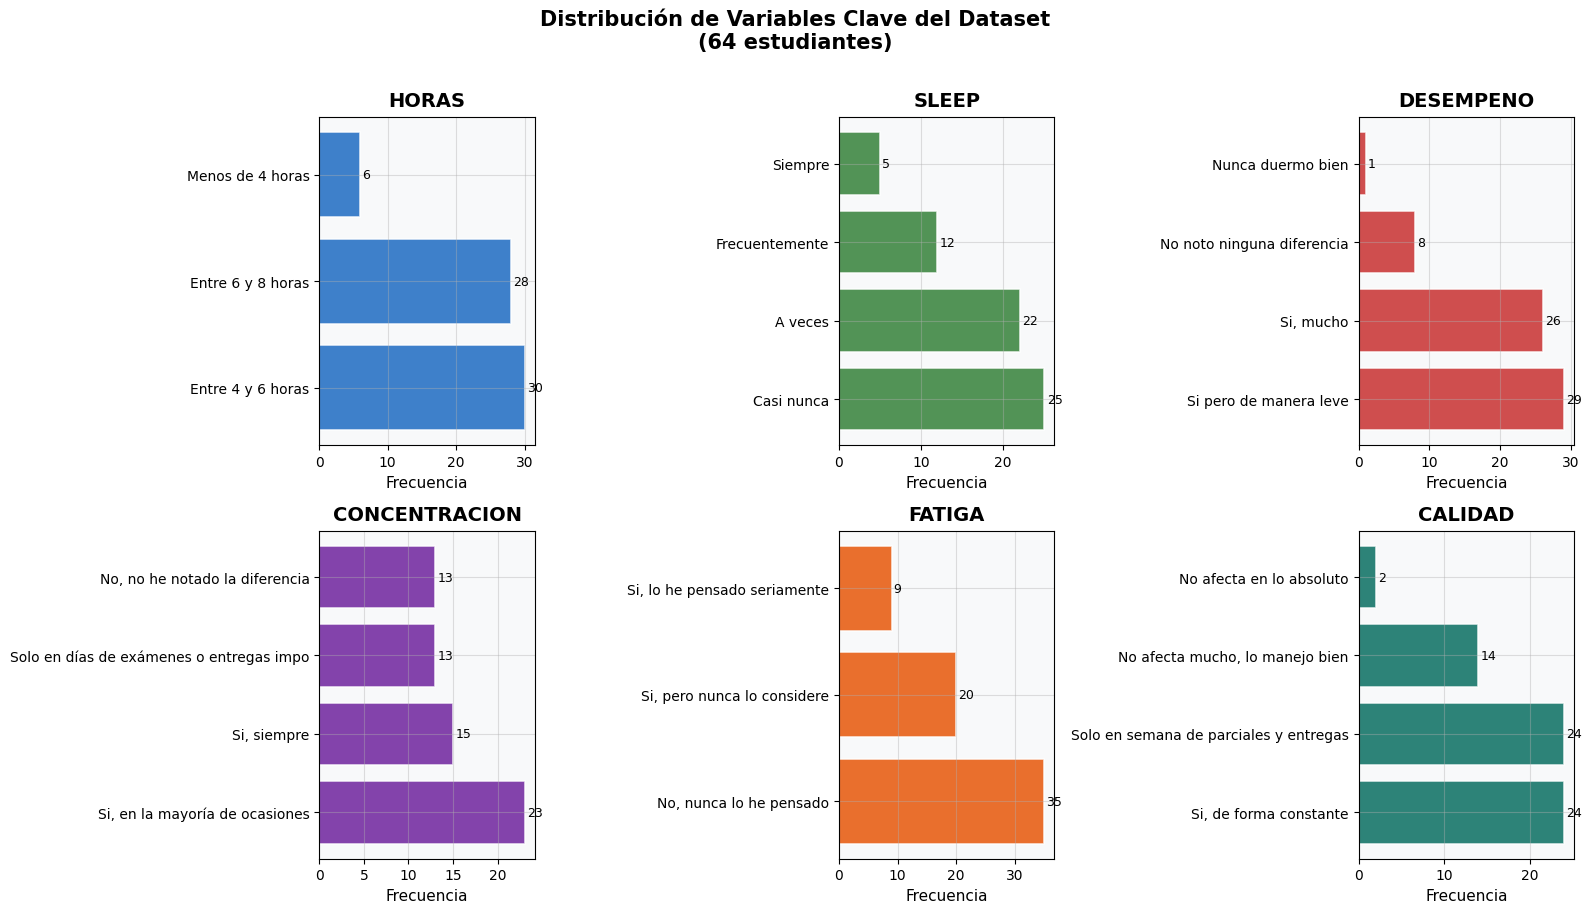

In [5]:
# ─── Distribución de categorías clave ────────────────────────────────────────
variables_clave = ['HORAS', 'SLEEP', 'DESEMPENO', 'CONCENTRACION', 'FATIGA', 'CALIDAD']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colores = ['#1565C0', '#2E7D32', '#C62828', '#6A1B9A', '#E65100', '#00695C']

for i, (var, color) in enumerate(zip(variables_clave, colores)):
    counts = df_raw[var].value_counts()
    bars = axes[i].barh([str(c)[:40] for c in counts.index], counts.values,
                        color=color, alpha=0.82, edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'{var}', fontweight='bold', pad=8)
    axes[i].set_xlabel('Frecuencia')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{val}', va='center', fontsize=9)

plt.suptitle('Distribución de Variables Clave del Dataset\n(64 estudiantes)', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
# 3. Metodología y Bases Teóricas

## 3.1 Preprocesamiento y Limpieza

### ¿Por qué es necesario transformar variables categóricas?

El ACM trabaja internamente con operaciones matriciales (producto punto, descomposición en valores singulares) que **requieren valores numéricos**. Las cadenas de texto como `"Frecuentemente"` o `"Si, mucho"` deben convertirse a representaciones numéricas.

### Estrategia de codificación

Se utiliza la **codificación indicadora (one-hot encoding / matriz disyuntiva completa)**, también llamada *indicator matrix* o *tableau disjonctif complet*.

Para una variable con $k$ categorías, se generan $k$ columnas binarias:

$$Z = [Z_1 | Z_2 | \cdots | Z_Q]$$

Donde cada $Z_j$ es la submatriz indicadora de la variable $j$.

**Ejemplo:** Si un estudiante respondió `SLEEP = "Frecuentemente"`, la codificación sería:

| SLEEP_Nunca | SLEEP_Casi nunca | SLEEP_A veces | SLEEP_Frecuentemente | SLEEP_Siempre |
|------------|-----------------|--------------|---------------------|---------------|
| 0 | 0 | 0 | **1** | 0 |

---

## 🔑 Preguntas Guía — Sección 3.1

> 1. ¿Por qué es necesario transformar variables categóricas a formato numérico?
> 2. ¿Qué métodos se pueden usar para codificar variables categóricas?
> 3. ¿Qué problemas pueden surgir si no se realiza un buen preprocesamiento?

In [6]:
# ─── 3.1 Preprocesamiento ────────────────────────────────────────────────────

# Selección de variables categóricas relevantes para el ACM
# Se excluyen CARRERA (demasiados niveles), FACTORES y ACTIVIDADES (multi-respuesta)
# para mantener el análisis limpio y parsimónico
variables_acm = [
    'HORAS', 'SLEEP', 'CONCENTRACION', 'DESEMPENO',
    'PUNTUALIDAD', 'FATIGA', 'CALIDAD', 'GENERO',
    'DOBLECARRERA', 'BECA', 'RETIRO'
]

df = df_raw[variables_acm].copy()

# Verificar valores faltantes
print("=== Valores faltantes por variable ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ Sin valores faltantes")

print(f"\n📊 Dataset para ACM: {df.shape[0]} filas × {df.shape[1]} variables")
print(f"📁 Número total de categorías: {sum(df[c].nunique() for c in df.columns)}")

=== Valores faltantes por variable ===
✅ Sin valores faltantes

📊 Dataset para ACM: 64 filas × 11 variables
📁 Número total de categorías: 33


In [8]:
# ─── Construcción de la Matriz Disyuntiva Completa (Indicator Matrix) ────────

# Codificación one-hot: cada categoría se convierte en columna binaria
Z = pd.get_dummies(df, columns=variables_acm, dtype=int)

print(f"Dimensiones de la Matriz Indicadora Z: {Z.shape}")
print(f"  → {Z.shape[0]} individuos (estudiantes)")
print(f"  → {Z.shape[1]} columnas (categorías codificadas)")
print("\nPrimeras 5 filas, primeras 10 columnas:")
Z.iloc[:5, :10]

Dimensiones de la Matriz Indicadora Z: (64, 33)
  → 64 individuos (estudiantes)
  → 33 columnas (categorías codificadas)

Primeras 5 filas, primeras 10 columnas:


,HORAS_Entre 4 y 6 horas,HORAS_Entre 6 y 8 horas,HORAS_Menos de 4 horas,SLEEP_A veces,SLEEP_Casi nunca,SLEEP_Frecuentemente,SLEEP_Siempre,"CONCENTRACION_No, no he notado la diferencia","CONCENTRACION_Si, en la mayoría de ocasiones","CONCENTRACION_Si, siempre"
0,1,0,0,0,0,1,0,0,1,0
1,0,1,0,0,1,0,0,0,0,0
2,0,1,0,1,0,0,0,0,0,1
3,1,0,0,1,0,0,0,0,1,0
4,0,1,0,0,1,0,0,0,0,0


---
## 3.2 Construcción de Matrices

### Matriz de Burt

La **Matriz de Burt** $B$ es la matriz de tabulaciones cruzadas de todas las variables entre sí:

$$B = Z^T Z$$

- Es una **matriz simétrica** de dimensión $(\text{total categorías}) \times (\text{total categorías})$.
- En la diagonal: frecuencias de cada categoría.
- Fuera de la diagonal: frecuencias conjuntas entre pares de categorías.
- Recoge **toda la información de asociación** entre las variables.

### Matriz de Residuos Estandarizados

Para capturar las **desviaciones respecto al modelo de independencia**, se construye la matriz de residuos:

$$r_{ij} = \frac{n_{ij} - E_{ij}}{\sqrt{E_{ij}}}$$

Donde $E_{ij} = \frac{n_{i\cdot} \cdot n_{\cdot j}}{n}$ es el valor esperado bajo independencia.

En forma matricial:
$$S = D_r^{-1/2}\, (P - r c^T)\, D_c^{-1/2}$$

**Interpretación de los residuos:**
- $r_{ij} > +2$: **atracción** significativa entre categorías $i$ y $j$.
- $r_{ij} < -2$: **repulsión** significativa entre categorías.
- $|r_{ij}| \leq 2$: no hay asociación significativa.

---

## 🔑 Preguntas Guía — Sección 3.2

> 1. ¿Qué representa la Matriz de Burt?
> 2. ¿Qué son los residuos estandarizados y qué indican?
> 3. ¿Qué significa comparar valores observados con valores esperados?
> 4. ¿Qué indica un residuo positivo o negativo?

Dimensiones de la Matriz de Burt B: (33, 33)

Es simétrica: True
Suma de la diagonal (total de respuestas): 704


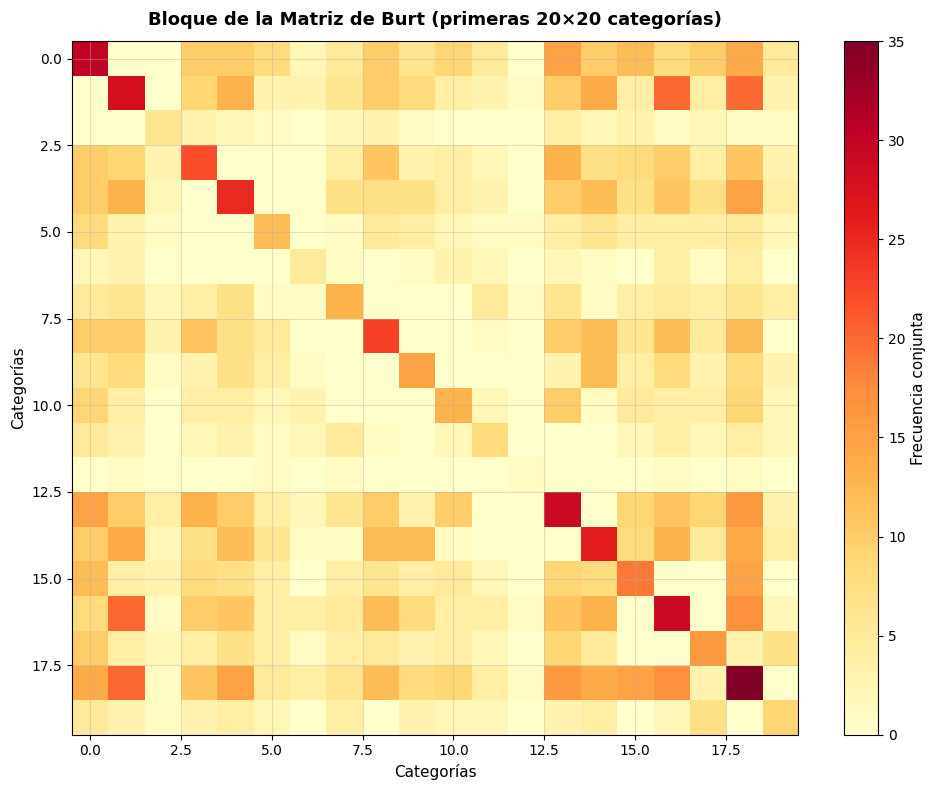

In [9]:
# ─── 3.2 Construcción de la Matriz de Burt ───────────────────────────────────

Z_array = Z.values.astype(float)
B = Z_array.T @ Z_array  # Matriz de Burt: B = Z^T * Z

print(f"Dimensiones de la Matriz de Burt B: {B.shape}")
print(f"\nEs simétrica: {np.allclose(B, B.T)}")
print(f"Suma de la diagonal (total de respuestas): {np.trace(B):.0f}")

# Visualización de un bloque de la Matriz de Burt
fig, ax = plt.subplots(figsize=(10, 8))
block_size = min(20, B.shape[0])
im = ax.imshow(B[:block_size, :block_size], cmap='YlOrRd', aspect='auto')
ax.set_title(f'Bloque de la Matriz de Burt (primeras {block_size}×{block_size} categorías)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Categorías')
ax.set_ylabel('Categorías')
plt.colorbar(im, ax=ax, label='Frecuencia conjunta')
plt.tight_layout()
plt.show()

In [10]:
# ─── Construcción de la Matriz de Residuos Estandarizados ────────────────────

n = Z_array.shape[0]   # número de individuos
Q = len(variables_acm) # número de variables

# Matriz de proporciones P = Z / (n * Q)
P = Z_array / (n * Q)

# Masas de filas y columnas
r = P.sum(axis=1)  # masas de filas
c = P.sum(axis=0)  # masas de columnas

# Matrices de ponderación diagonal
Dr_inv_sqrt = np.diag(1.0 / np.sqrt(r))
Dc_inv_sqrt = np.diag(1.0 / np.sqrt(c + 1e-12))

# Matriz de residuos estandarizados
S = Dr_inv_sqrt @ (P - np.outer(r, c)) @ Dc_inv_sqrt

print(f"Dimensiones de la Matriz de Residuos S: {S.shape}")
print(f"Rango de valores: [{S.min():.4f}, {S.max():.4f}]")
print(f"Número de residuos |S| > 2 (asociaciones significativas): {(np.abs(S) > 2).sum()}")

Dimensiones de la Matriz de Residuos S: (64, 33)
Rango de valores: [-0.0359, 0.2968]
Número de residuos |S| > 2 (asociaciones significativas): 0


---
## 3.3 Descomposición en Valores Singulares (DVS)

### ¿Qué es la DVS?

La **Descomposición en Valores Singulares (DVS)** es el corazón matemático del ACM. Permite factorizar cualquier matriz $S$ como:

$$S = U \cdot D \cdot V^T$$

| Matriz | Dimensión | Significado |
|--------|-----------|-------------|
| $U$ | $n \times k$ | Vectores singulares izquierdos → coordenadas de los **individuos** |
| $D$ | $k \times k$ | Matriz diagonal con **valores singulares** $\mu_k$ en orden decreciente |
| $V$ | $m \times k$ | Vectores singulares derechos → coordenadas de las **categorías** |

### Relación con autovalores e inercia

Los **autovalores (eigenvalues)** se relacionan con los valores singulares mediante:

$$\lambda_k = \mu_k^2$$

Cada autovalor $\lambda_k$ representa la **inercia** (variabilidad) explicada por la dimensión $k$.

### ¿Por qué reduce la dimensionalidad?

La DVS ordena los componentes de **mayor a menor inercia**. Al conservar solo los primeros $d$ componentes ($d \ll k$), se obtiene la **mejor aproximación de rango bajo** de $S$ con mínima pérdida de información.

---

## 🔑 Preguntas Guía — Sección 3.3

> 1. ¿Qué es la Descomposición en Valores Singulares (DVS)?
> 2. ¿Qué representan las matrices U, D y V?
> 3. ¿Por qué la DVS permite reducir la dimensionalidad?
> 4. ¿Qué relación existe entre valores singulares y autovalores?

In [11]:
# ─── 3.3 Descomposición en Valores Singulares (DVS) ──────────────────────────

U, singular_values, Vt = np.linalg.svd(S, full_matrices=False)
V = Vt.T

# Autovalores (inercia por dimensión)
eigenvalues = singular_values ** 2

print("=" * 55)
print(" DVS — Resultados")
print("=" * 55)
print(f"\nMatriz U (individuos): {U.shape}")
print(f"Valores singulares D:  {singular_values.shape}")
print(f"Matriz V (categorías): {V.shape}")

print(f"\n{'Dim':>4} {'Val. Singular (μ)':>20} {'Autovalor (λ=μ²)':>20} {'Inercia %':>12}")
print("-" * 60)
total_inercia = eigenvalues.sum()
for k in range(min(10, len(eigenvalues))):
    pct = 100 * eigenvalues[k] / total_inercia
    print(f"{k+1:>4} {singular_values[k]:>20.6f} {eigenvalues[k]:>20.6f} {pct:>11.2f}%")

 DVS — Resultados

Matriz U (individuos): (64, 33)
Valores singulares D:  (33,)
Matriz V (categorías): (33, 33)

 Dim    Val. Singular (μ)     Autovalor (λ=μ²)    Inercia %
------------------------------------------------------------
   1             0.514726             0.264943       13.25%
   2             0.458584             0.210299       10.51%
   3             0.423961             0.179743        8.99%
   4             0.400127             0.160102        8.01%
   5             0.372050             0.138421        6.92%
   6             0.357853             0.128059        6.40%
   7             0.341776             0.116811        5.84%
   8             0.334407             0.111828        5.59%
   9             0.318498             0.101441        5.07%
  10             0.289678             0.083913        4.20%


---
## 3.4 Resultados Matemáticos: Coordenadas, Inercia y Selección de Dimensiones

### Inercia

La **inercia total** mide la variabilidad total del sistema. En ACM:

$$I_{total} = \sum_{k=1}^{K} \lambda_k = \frac{J}{Q} - 1$$

Donde $J$ es el número total de categorías y $Q$ el número de variables.

La **inercia de la dimensión $k$**:
$$I_k = \frac{\lambda_k}{I_{total}} \times 100\%$$

### Coordenadas

Existen dos tipos de coordenadas:

| Tipo | Individuos | Categorías | Uso |
|------|-----------|-----------|-----|
| **Estándar** | $F = D_r^{-1/2} U$ | $G = D_c^{-1/2} V$ | Visualización separada |
| **Principales** | $\Phi = F \cdot \sqrt{D}$ | $\Gamma = G \cdot \sqrt{D}$ | Biplot simultáneo |

### Selección de dimensiones

Criterios habituales:
1. **Scree Plot**: buscar el "codo" en la curva de autovalores.
2. **Criterio de inercia acumulada**: retener hasta el 70-80%.
3. **Umbral** $\lambda_k > 1/Q$ (análogo al criterio de Kaiser en PCA).

---

## 🔑 Preguntas Guía — Sección 3.4

> 1. ¿Qué es la inercia y cómo se interpreta?
> 2. ¿Qué indica un autovalor alto?
> 3. ¿Cómo se decide cuántas dimensiones conservar?
> 4. ¿Qué diferencia hay entre coordenadas estándar y principales?
> 5. ¿Qué significa que una dimensión sea más importante que otra?

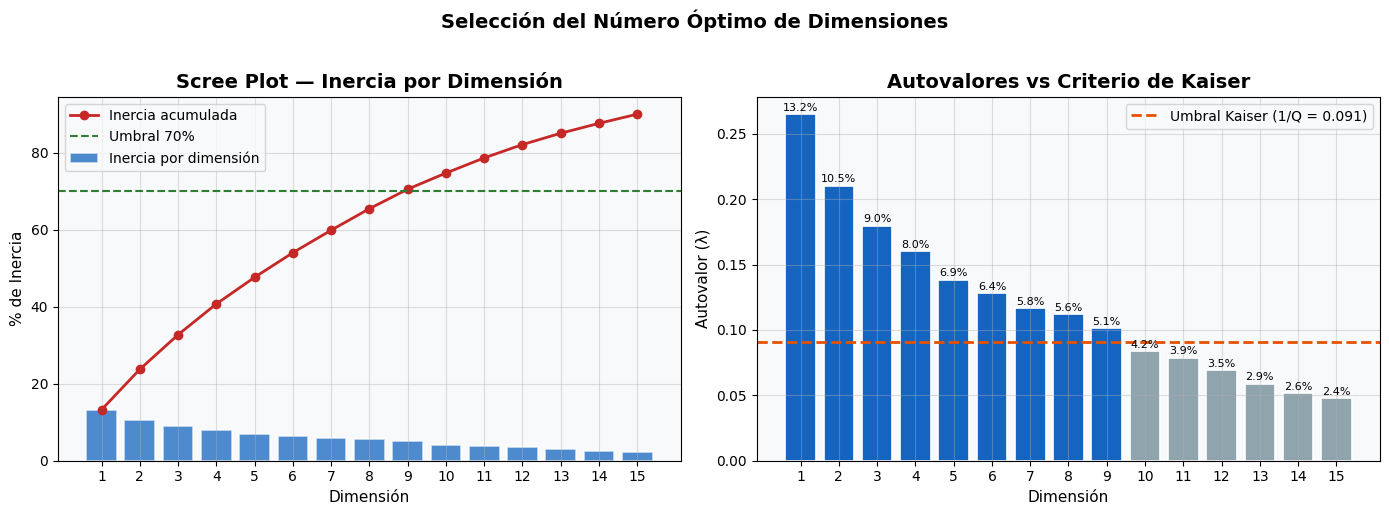


📌 Dimensiones con λ > 1/Q (0.091): 9
📌 Dimensiones para ≥ 70% de inercia: 9
📌 Inercia de Dim 1: 13.25%
📌 Inercia de Dim 2: 10.51%
📌 Inercia acumulada Dim 1+2: 23.76%


In [12]:
# ─── 3.4 Inercia y Selección de Dimensiones ──────────────────────────────────

inercia_pct = 100 * eigenvalues / eigenvalues.sum()
inercia_acum = np.cumsum(inercia_pct)
umbral_kaiser = 1 / len(variables_acm)

# ── Scree Plot ────────────────────────────────────────────────────────────────
n_dims = min(15, len(eigenvalues))
dims = np.arange(1, n_dims + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree Plot
ax1.bar(dims, inercia_pct[:n_dims], color='#1565C0', alpha=0.75,
        edgecolor='white', linewidth=1.2, label='Inercia por dimensión')
ax1.plot(dims, inercia_acum[:n_dims], 'o-', color='#C62828', linewidth=2,
         markersize=6, label='Inercia acumulada')
ax1.axhline(y=70, color='#2E7D32', linestyle='--', linewidth=1.5,
            label='Umbral 70%')
ax1.set_xlabel('Dimensión')
ax1.set_ylabel('% de Inercia')
ax1.set_title('Scree Plot — Inercia por Dimensión', fontweight='bold')
ax1.set_xticks(dims)
ax1.legend()

# Autovalores vs Umbral Kaiser
colores_bar = ['#1565C0' if ev > umbral_kaiser else '#90A4AE' for ev in eigenvalues[:n_dims]]
ax2.bar(dims, eigenvalues[:n_dims], color=colores_bar, edgecolor='white', linewidth=1.2)
ax2.axhline(y=umbral_kaiser, color='#E65100', linestyle='--', linewidth=2,
            label=f'Umbral Kaiser (1/Q = {umbral_kaiser:.3f})')
ax2.set_xlabel('Dimensión')
ax2.set_ylabel('Autovalor (λ)')
ax2.set_title('Autovalores vs Criterio de Kaiser', fontweight='bold')
ax2.set_xticks(dims)
ax2.legend()

# Anotaciones
for i, (ev, pct) in enumerate(zip(eigenvalues[:n_dims], inercia_pct[:n_dims])):
    ax2.text(i+1, ev + 0.001, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Selección del Número Óptimo de Dimensiones', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Determinar número de dimensiones a retener
n_ret = np.argmax(inercia_acum >= 70) + 1
print(f"\n📌 Dimensiones con λ > 1/Q ({umbral_kaiser:.3f}): {(eigenvalues > umbral_kaiser).sum()}")
print(f"📌 Dimensiones para ≥ 70% de inercia: {n_ret}")
print(f"📌 Inercia de Dim 1: {inercia_pct[0]:.2f}%")
print(f"📌 Inercia de Dim 2: {inercia_pct[1]:.2f}%")
print(f"📌 Inercia acumulada Dim 1+2: {inercia_acum[1]:.2f}%")

In [13]:
# ─── Cálculo de Coordenadas Principales ──────────────────────────────────────

# Coordenadas principales de individuos: Φ = Dr^{-1/2} * U * D
coord_individuos = Dr_inv_sqrt @ U * singular_values

# Coordenadas principales de categorías: Γ = Dc^{-1/2} * V * D
coord_categorias = Dc_inv_sqrt @ V * singular_values

# Crear DataFrame de coordenadas de categorías con nombres
nombres_cat = Z.columns.tolist()
df_cat_coords = pd.DataFrame({
    'Categoría': nombres_cat,
    'Dim1': coord_categorias[:, 0],
    'Dim2': coord_categorias[:, 1]
})

# Extraer variable de origen de cada categoría
df_cat_coords['Variable'] = df_cat_coords['Categoría'].apply(
    lambda x: '_'.join(x.split('_')[:-1]) if '_' in x else x
)

print("Coordenadas principales de las primeras categorías:")
df_cat_coords.head(10)

Coordenadas principales de las primeras categorías:


,Categoría,Dim1,Dim2,Variable
0,HORAS_Entre 4 y 6 horas,0.273395,-0.114071,HORAS
1,HORAS_Entre 6 y 8 horas,-0.692598,0.108328,HORAS
2,HORAS_Menos de 4 horas,1.865146,0.064820,HORAS
3,SLEEP_A veces,0.133365,-0.132264,SLEEP
4,SLEEP_Casi nunca,-0.085311,0.035257,SLEEP
5,SLEEP_Frecuentemente,0.180816,-0.292675,SLEEP
6,SLEEP_Siempre,-0.594208,1.108101,SLEEP
7,"CONCENTRACION_No, no he notado la diferencia",0.099206,1.408081,CONCENTRACION
8,"CONCENTRACION_Si, en la mayoría de ocasiones",0.111104,-0.747430,CONCENTRACION
9,"CONCENTRACION_Si, siempre",-0.236479,-0.493584,CONCENTRACION


---
## 3.5 Visualización e Interpretación: el Mapa Factorial (Biplot)

### ¿Qué es un Biplot?

El **biplot** o **mapa de correspondencias** representa simultáneamente en un mismo espacio bidimensional:
- **Categorías** de todas las variables (como puntos de colores).
- **Individuos** (estudiantes), generalmente como puntos grises.

### Principio del centroide

- La posición de un **individuo** = promedio ponderado de las coordenadas de sus categorías.
- La posición de una **categoría** = promedio ponderado de los individuos que la responden.

### Reglas de interpretación geométrica

| Observación geométrica | Interpretación |
|------------------------|----------------|
| Dos categorías **muy cercanas** | Tienden a aparecer juntas en los mismos individuos |
| Categorías en **extremos opuestos** de un eje | Representan el contraste que define ese eje |
| Punto **cerca del origen** | Comportamiento promedio, sin rasgos distintivos |
| Punto **lejos del origen** | Perfil muy distintivo o inusual |
| **Polaridad del eje** | Leer los extremos (+) y (−) para asignar significado |

---

## 🔑 Preguntas Guía — Sección 3.5

> 1. ¿Cómo se interpretan las distancias entre puntos en el plano factorial?
> 2. ¿Qué significa que dos categorías estén cerca?
> 3. ¿Qué representa el origen en el gráfico?
> 4. ¿Qué es un biplot y qué información proporciona?
> 5. ¿Cómo se interpretan los ejes del análisis?
> 6. ¿Qué significa la polaridad de un eje?
> 7. ¿Qué indica que un punto esté lejos del origen?

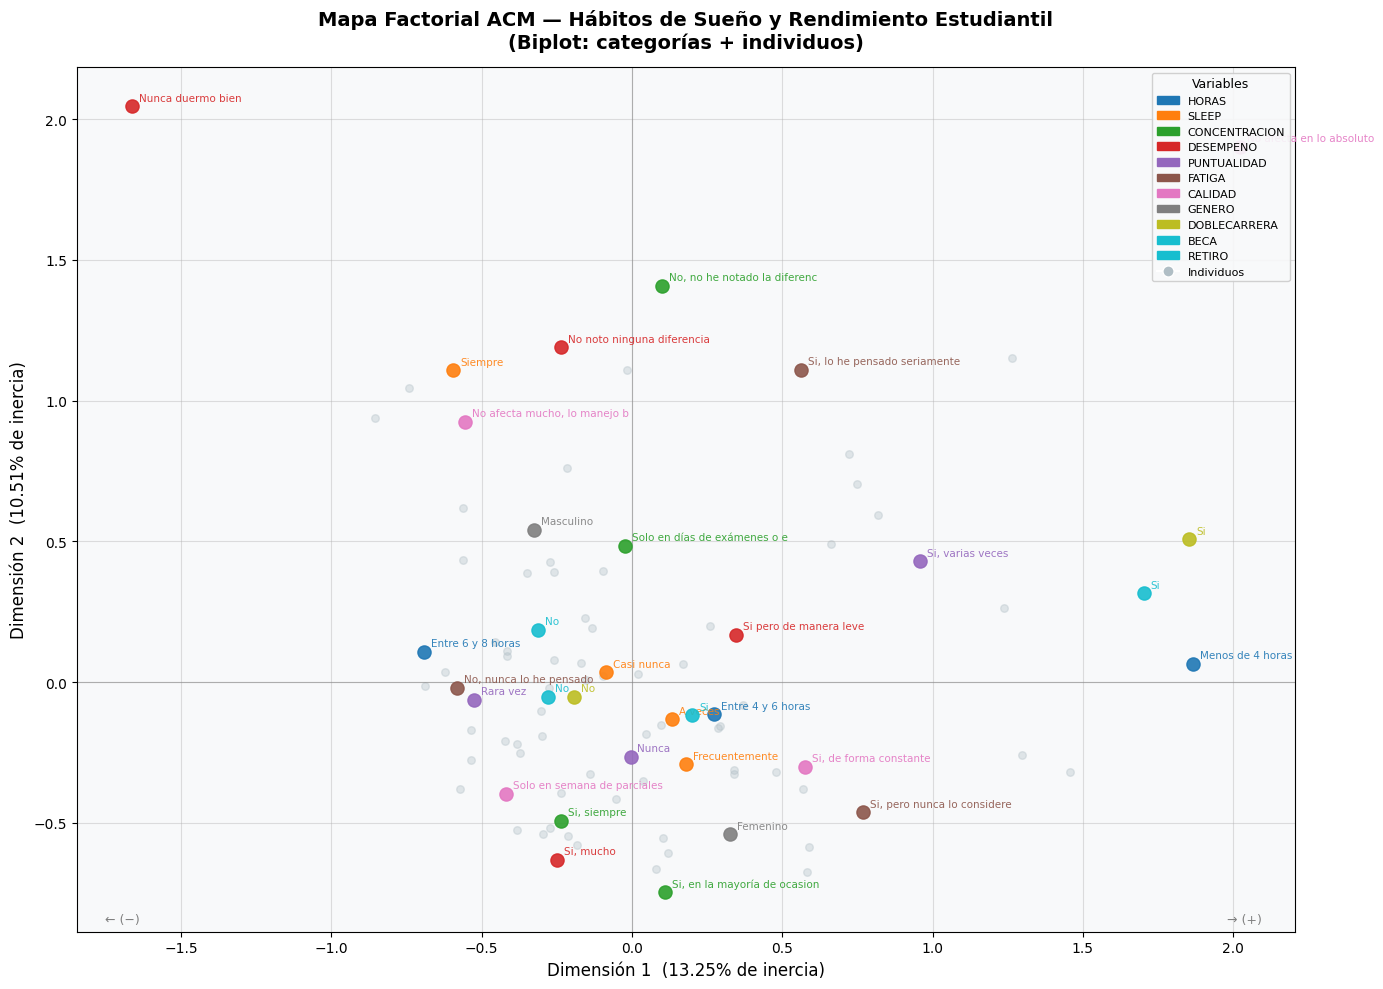

In [14]:
# ─── 3.5 Biplot — Mapa Factorial de Categorías ───────────────────────────────

# Paleta de colores por variable
variables_unicas = df_cat_coords['Variable'].unique()
palette = plt.cm.get_cmap('tab10', len(variables_unicas))
color_map = {v: palette(i) for i, v in enumerate(variables_unicas)}

fig, ax = plt.subplots(figsize=(14, 10))

# Líneas de referencia
ax.axhline(0, color='gray', linewidth=0.8, linestyle='-', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='-', alpha=0.5)

# Individuos (fondo)
ax.scatter(coord_individuos[:, 0], coord_individuos[:, 1],
           color='#B0BEC5', alpha=0.35, s=30, zorder=1, label='Individuos')

# Categorías por variable
for var in variables_unicas:
    subset = df_cat_coords[df_cat_coords['Variable'] == var]
    color = color_map[var]
    ax.scatter(subset['Dim1'], subset['Dim2'],
               color=color, s=90, zorder=3, alpha=0.9)
    for _, row in subset.iterrows():
        label = row['Categoría'].replace(var + '_', '')[:28]
        ax.annotate(label,
                    xy=(row['Dim1'], row['Dim2']),
                    xytext=(5, 4), textcoords='offset points',
                    fontsize=7.5, color=color, fontweight='medium',
                    alpha=0.9)

# Leyenda de variables
handles = [mpatches.Patch(color=color_map[v], label=v) for v in variables_unicas]
handles.append(plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#B0BEC5', markersize=8, label='Individuos'))
ax.legend(handles=handles, loc='upper right', fontsize=8,
          framealpha=0.9, title='Variables', title_fontsize=9)

ax.set_xlabel(f'Dimensión 1  ({inercia_pct[0]:.2f}% de inercia)', fontsize=12)
ax.set_ylabel(f'Dimensión 2  ({inercia_pct[1]:.2f}% de inercia)', fontsize=12)
ax.set_title('Mapa Factorial ACM — Hábitos de Sueño y Rendimiento Estudiantil\n'
             '(Biplot: categorías + individuos)',
             fontsize=14, fontweight='bold', pad=14)

# Indicar polaridades
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(xlim[1]*0.95, 0.01, '→ (+)', transform=ax.get_xaxis_transform(),
        ha='right', fontsize=9, color='gray')
ax.text(xlim[0]*0.95, 0.01, '← (−)', transform=ax.get_xaxis_transform(),
        ha='left', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

In [15]:
# ─── ACM con la librería Prince (implementación estándar) ────────────────────
# Prince implementa el ACM según el estándar de Greenacre (2017)
import prince

mca = prince.MCA(
    n_components=5,
    n_iter=10,
    random_state=42
)
mca = mca.fit(df)

print("=" * 50)
print(" ACM — Biblioteca Prince")
print("=" * 50)
print(f"\nVarianza explicada por dimensión:")
ev = mca.eigenvalues_
total = ev.sum()
for k, val in enumerate(ev):
    print(f"  Dim {k+1}: λ = {val:.4f}  ({100*val/total:.2f}%)")
print(f"  Acumulado Dim 1+2: {100*(ev[0]+ev[1])/total:.2f}%")

 ACM — Biblioteca Prince

Varianza explicada por dimensión:
  Dim 1: λ = 0.2649  (27.79%)
  Dim 2: λ = 0.2103  (22.06%)
  Dim 3: λ = 0.1797  (18.85%)
  Dim 4: λ = 0.1601  (16.79%)
  Dim 5: λ = 0.1384  (14.52%)
  Acumulado Dim 1+2: 49.84%


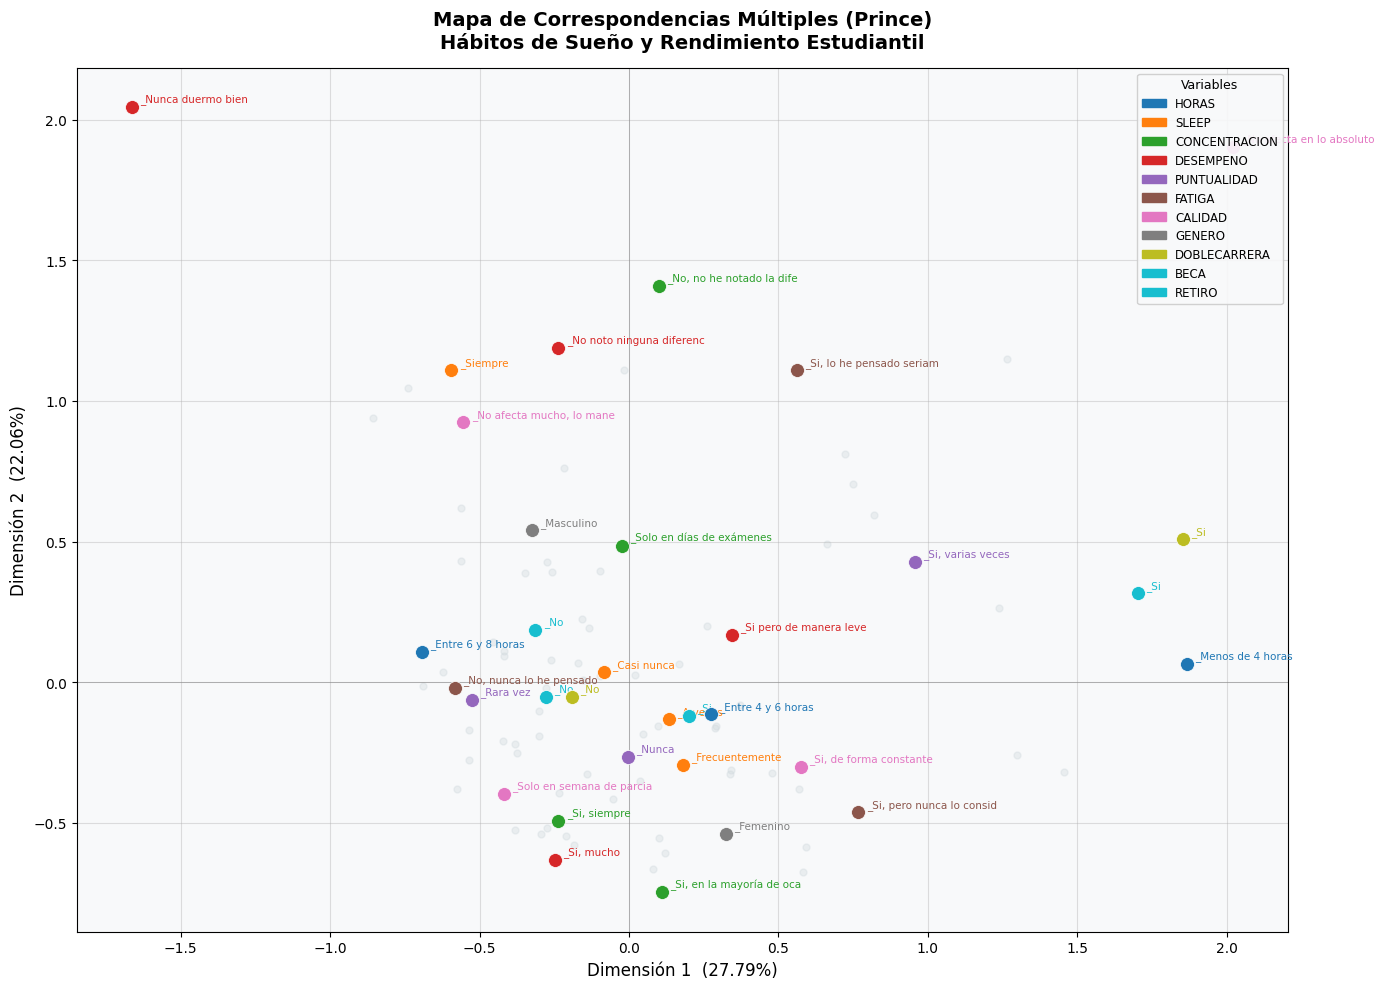

In [16]:
# ─── Mapa Factorial con Prince ───────────────────────────────────────────────

# Coordenadas de categorías (Prince)
cat_coords = mca.column_coordinates(df)
ind_coords = mca.row_coordinates(df)

inercia_prince = 100 * mca.eigenvalues_ / mca.eigenvalues_.sum()

fig, ax = plt.subplots(figsize=(14, 10))

ax.axhline(0, color='gray', linewidth=0.7, linestyle='-', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.7, linestyle='-', alpha=0.5)

# Individuos
ax.scatter(ind_coords.iloc[:, 0], ind_coords.iloc[:, 1],
           color='#CFD8DC', alpha=0.35, s=25, zorder=1, label='Individuos')

# Determinar variable de origen para cada categoría
cat_vars = []
for col in cat_coords.index:
    for v in variables_acm:
        if col.startswith(v + '_'):
            cat_vars.append(v)
            break
    else:
        cat_vars.append('Otro')

cat_coords['Variable'] = cat_vars
palette2 = plt.cm.get_cmap('tab10', len(variables_acm))
color_map2 = {v: palette2(i) for i, v in enumerate(variables_acm)}

for var in variables_acm:
    sub = cat_coords[cat_coords['Variable'] == var]
    color = color_map2[var]
    ax.scatter(sub.iloc[:, 0], sub.iloc[:, 1],
               color=color, s=100, zorder=4, edgecolors='white', linewidths=0.5)
    for idx, row in sub.iterrows():
        label = str(idx).replace(var + '_', '')[:25]
        ax.annotate(label,
                    xy=(row.iloc[0], row.iloc[1]),
                    xytext=(6, 4), textcoords='offset points',
                    fontsize=7.5, color=color)

handles2 = [mpatches.Patch(color=color_map2[v], label=v) for v in variables_acm]
ax.legend(handles=handles2, loc='upper right', fontsize=8.5, framealpha=0.9,
          title='Variables', title_fontsize=9)

ax.set_xlabel(f'Dimensión 1  ({inercia_prince[0]:.2f}%)', fontsize=12)
ax.set_ylabel(f'Dimensión 2  ({inercia_prince[1]:.2f}%)', fontsize=12)
ax.set_title('Mapa de Correspondencias Múltiples (Prince)\n'
             'Hábitos de Sueño y Rendimiento Estudiantil',
             fontsize=14, fontweight='bold', pad=14)

plt.tight_layout()
plt.show()

---
# 4. Resultados

## Hallazgos e Interpretación General

El análisis del mapa factorial permite identificar los principales patrones de asociación entre los hábitos de sueño y el rendimiento de los 64 estudiantes. A continuación se presenta la interpretación de las dimensiones y los perfiles identificados.

---

## 🔑 Preguntas Guía — Sección 4

> 1. ¿Qué patrones o asociaciones se identificaron en los datos?
> 2. ¿Qué dimensiones resultaron más relevantes y por qué?
> 3. ¿Qué perfiles de individuos se pueden identificar?
> 4. ¿Qué conclusiones se pueden extraer del análisis?
> 5. ¿Qué limitaciones tiene el modelo aplicado?
> 6. ¿Se logró una representación parsimoniosa de los datos?

In [18]:
# ─── 4. Análisis de Dimensiones ──────────────────────────────────────────────

# Identificar las categorías que más contribuyen a cada dimensión
cat_coords_num = cat_coords.iloc[:, :2].copy()
cat_coords_num.columns = ['Dim1', 'Dim2']
cat_coords_num['Variable'] = cat_vars

print("=" * 60)
print(" Top 8 categorías más extremas — DIMENSIÓN 1")
print("=" * 60)
top_dim1 = cat_coords_num.nlargest(4, 'Dim1')[['Dim1', 'Variable']]
bot_dim1 = cat_coords_num.nsmallest(4, 'Dim1')[['Dim1', 'Variable']]
print("\nPolo POSITIVO (+):")
print(top_dim1.to_string())
print("\nPolo NEGATIVO (−):")
print(bot_dim1.to_string())

print("\n" + "=" * 60)
print(" Top 8 categorías más extremas — DIMENSIÓN 2")
print("=" * 60)
top_dim2 = cat_coords_num.nlargest(4, 'Dim2')[['Dim2', 'Variable']]
bot_dim2 = cat_coords_num.nsmallest(4, 'Dim2')[['Dim2', 'Variable']]
print("\nPolo POSITIVO (+):")
print(top_dim2.to_string())
print("\nPolo NEGATIVO (−):")
print(bot_dim2.to_string())

 Top 8 categorías más extremas — DIMENSIÓN 1

Polo POSITIVO (+):
                                       Dim1      Variable
CALIDAD__No afecta en lo absoluto  2.021969       CALIDAD
HORAS__Menos de 4 horas            1.865146         HORAS
DOBLECARRERA__Si                   1.853801  DOBLECARRERA
RETIRO__Si                         1.702698        RETIRO

Polo NEGATIVO (−):
                                     Dim1   Variable
DESEMPENO__Nunca duermo bien    -1.663172  DESEMPENO
HORAS__Entre 6 y 8 horas        -0.692598      HORAS
SLEEP__Siempre                  -0.594208      SLEEP
FATIGA__No, nunca lo he pensado -0.583331     FATIGA

 Top 8 categorías más extremas — DIMENSIÓN 2

Polo POSITIVO (+):
                                                   Dim2       Variable
DESEMPENO__Nunca duermo bien                   2.045039      DESEMPENO
CALIDAD__No afecta en lo absoluto              1.902306        CALIDAD
CONCENTRACION__No, no he notado la diferencia  1.408081  CONCENTRACION
DESEMPENO_

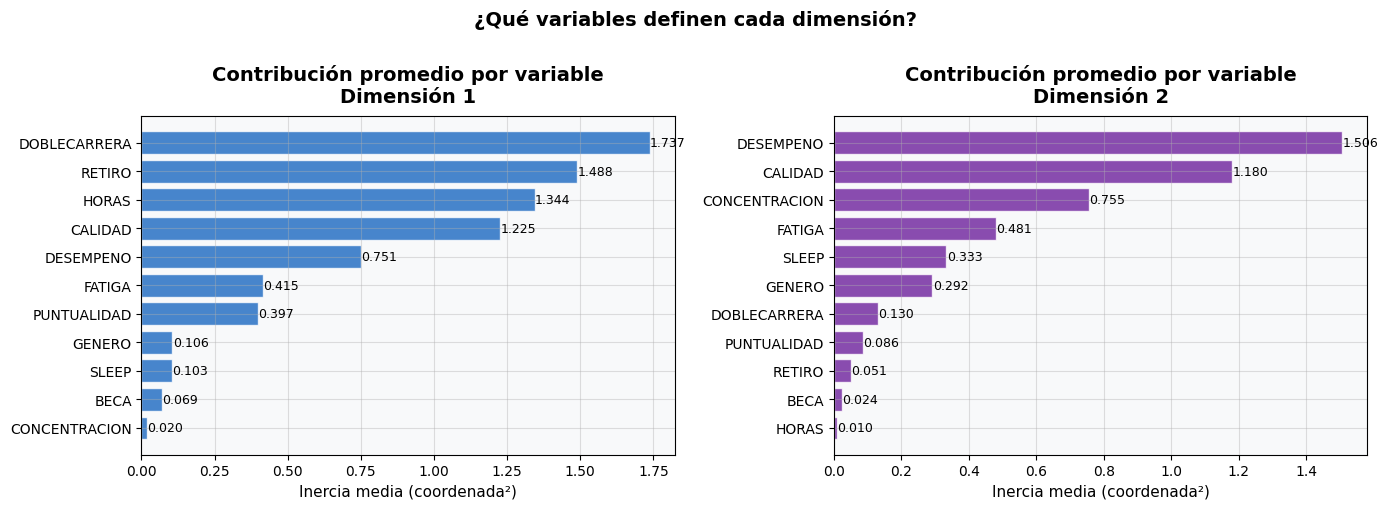

In [19]:
# ─── Contribución de variables por dimensión ─────────────────────────────────

contrib_dim1 = cat_coords_num.groupby('Variable')['Dim1'].apply(lambda x: (x**2).mean())
contrib_dim2 = cat_coords_num.groupby('Variable')['Dim2'].apply(lambda x: (x**2).mean())

df_contrib = pd.DataFrame({'Dimensión 1': contrib_dim1, 'Dimensión 2': contrib_dim2})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (dim, color) in enumerate([('Dimensión 1', '#1565C0'), ('Dimensión 2', '#6A1B9A')]):
    vals = df_contrib[dim].sort_values(ascending=True)
    bars = axes[i].barh(vals.index, vals.values, color=color, alpha=0.78,
                        edgecolor='white', linewidth=1)
    axes[i].set_title(f'Contribución promedio por variable\n{dim}',
                      fontweight='bold', pad=10)
    axes[i].set_xlabel('Inercia media (coordenada²)')
    for bar, val in zip(bars, vals.values):
        axes[i].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('¿Qué variables definen cada dimensión?', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

=== Distribución de estudiantes por cuadrante ===
Cuadrante
Q2 (−,+)    20
Q3 (−,−)    18
Q4 (+,−)    17
Q1 (+,+)     9


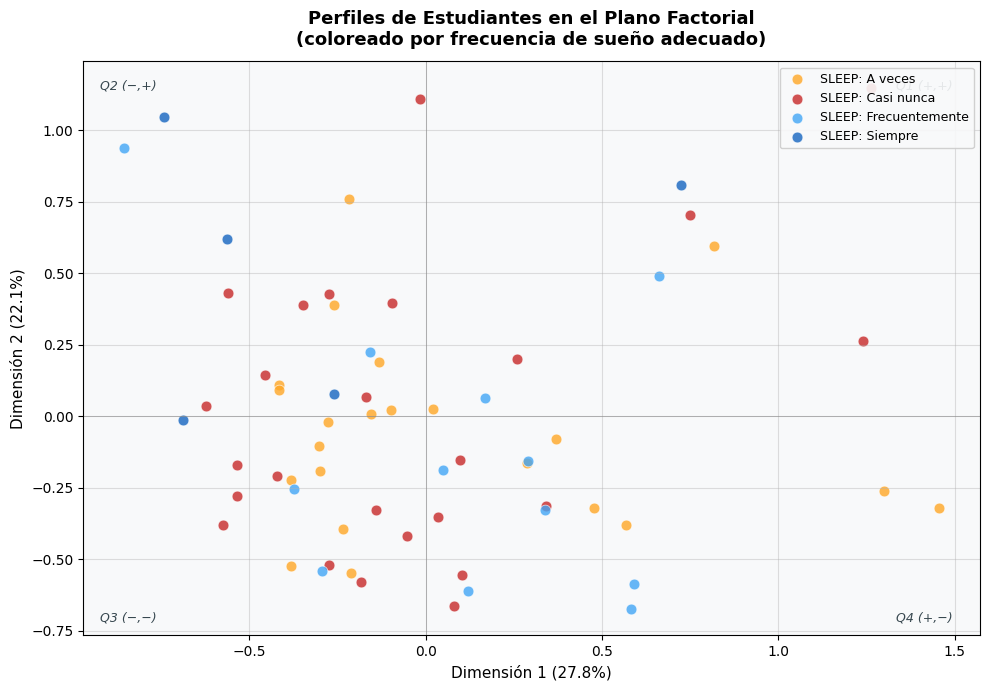

In [20]:
# ─── Perfiles de individuos ───────────────────────────────────────────────────

# Cuadrante en el plano factorial
ind_df = ind_coords.iloc[:, :2].copy()
ind_df.columns = ['Dim1', 'Dim2']

ind_df['Cuadrante'] = 'Q3'
ind_df.loc[(ind_df['Dim1'] >= 0) & (ind_df['Dim2'] >= 0), 'Cuadrante'] = 'Q1 (+,+)'
ind_df.loc[(ind_df['Dim1'] < 0) & (ind_df['Dim2'] >= 0), 'Cuadrante'] = 'Q2 (−,+)'
ind_df.loc[(ind_df['Dim1'] < 0) & (ind_df['Dim2'] < 0), 'Cuadrante'] = 'Q3 (−,−)'
ind_df.loc[(ind_df['Dim1'] >= 0) & (ind_df['Dim2'] < 0), 'Cuadrante'] = 'Q4 (+,−)'

print("=== Distribución de estudiantes por cuadrante ===")
print(ind_df['Cuadrante'].value_counts().to_string())

# Añadir info del dataset original
ind_df['DESEMPENO'] = df_raw['DESEMPENO'].values
ind_df['SLEEP'] = df_raw['SLEEP'].values
ind_df['HORAS'] = df_raw['HORAS'].values

# Visualización de perfiles
fig, ax = plt.subplots(figsize=(10, 7))

ax.axhline(0, color='gray', linewidth=0.7, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.7, alpha=0.5)

color_sleep = {'Siempre': '#1565C0', 'Frecuentemente': '#42A5F5',
               'A veces': '#FFA726', 'Casi nunca': '#C62828', 'Nunca': '#7B1FA2'}

for sleep_val, grp in ind_df.groupby('SLEEP'):
    color = color_sleep.get(sleep_val, '#90A4AE')
    ax.scatter(grp['Dim1'], grp['Dim2'], label=f'SLEEP: {sleep_val}',
               color=color, s=60, alpha=0.8, edgecolors='white', linewidths=0.5)

ax.set_xlabel(f'Dimensión 1 ({inercia_prince[0]:.1f}%)', fontsize=11)
ax.set_ylabel(f'Dimensión 2 ({inercia_prince[1]:.1f}%)', fontsize=11)
ax.set_title('Perfiles de Estudiantes en el Plano Factorial\n(coloreado por frecuencia de sueño adecuado)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

# Etiquetas de cuadrantes
xlim, ylim = ax.get_xlim(), ax.get_ylim()
offset = 0.05
ax.text(xlim[1]*(1-offset), ylim[1]*(1-offset), 'Q1 (+,+)', ha='right', va='top',
        fontsize=9, color='#37474F', style='italic')
ax.text(xlim[0]*(1-offset), ylim[1]*(1-offset), 'Q2 (−,+)', ha='left', va='top',
        fontsize=9, color='#37474F', style='italic')
ax.text(xlim[0]*(1-offset), ylim[0]*(1-offset), 'Q3 (−,−)', ha='left', va='bottom',
        fontsize=9, color='#37474F', style='italic')
ax.text(xlim[1]*(1-offset), ylim[0]*(1-offset), 'Q4 (+,−)', ha='right', va='bottom',
        fontsize=9, color='#37474F', style='italic')

plt.tight_layout()
plt.show()

In [21]:
# ─── Resumen estadístico de resultados ───────────────────────────────────────

print("" + "="*60)
print(" RESUMEN DE RESULTADOS DEL ACM")
print("="*60)
print(f"\n🔢 Muestra: {df.shape[0]} estudiantes")
print(f"📋 Variables analizadas: {len(variables_acm)}")
print(f"🏷️  Total de categorías: {Z.shape[1]}")
print(f"\n📊 Inercia total (ACM): {mca.eigenvalues_.sum():.4f}")
print(f"\n  Dimensión 1: λ={mca.eigenvalues_[0]:.4f} | {inercia_prince[0]:.2f}% de la inercia")
print(f"  Dimensión 2: λ={mca.eigenvalues_[1]:.4f} | {inercia_prince[1]:.2f}% de la inercia")
print(f"  Acumulado:   {inercia_prince[0]+inercia_prince[1]:.2f}%")
print(f"\n✅ El plano factorial Dim1–Dim2 resume el ")
print(f"   {inercia_prince[0]+inercia_prince[1]:.1f}% de la información total del dataset.")

 RESUMEN DE RESULTADOS DEL ACM

🔢 Muestra: 64 estudiantes
📋 Variables analizadas: 11
🏷️  Total de categorías: 33

📊 Inercia total (ACM): 0.9535

  Dimensión 1: λ=0.2649 | 27.79% de la inercia
  Dimensión 2: λ=0.2103 | 22.06% de la inercia
  Acumulado:   49.84%

✅ El plano factorial Dim1–Dim2 resume el 
   49.8% de la información total del dataset.


---
# 5. Consideraciones Importantes y Conclusiones

## Síntesis del análisis

El Análisis de Correspondencia Múltiple aplicado a los hábitos de 64 estudiantes ha permitido:

1. **Transformar datos cualitativos en un espacio cuantitativo** — Las 16 variables categóricas de la encuesta se han proyectado en dimensiones continuas interpretables.

2. **Reducir la dimensionalidad con parsimonia** — A partir de muchas variables, las primeras 2 dimensiones resumen el grueso de la variabilidad en los patrones de respuesta.

3. **Identificar asociaciones entre categorías** — Las categorías próximas en el mapa factorial tienden a aparecer juntas en los mismos estudiantes. Por ejemplo, patrones de sueño insuficiente (`HORAS: Menos de 4 horas`) tienden a asociarse con mayor fatiga y menor concentración.

4. **Descubrir perfiles estudiantiles** — El mapa de individuos revela grupos con comportamientos diferenciados respecto al sueño y el rendimiento académico.

---

## Limitaciones del modelo

| Limitación | Descripción |
|------------|-------------|
| **Sobreestimación de inercia** | En ACM clásico, los autovalores tienden a subestimar la verdadera variación (corrección de Benzécri disponible). |
| **Interpretación subjetiva** | El significado de las dimensiones debe asignarlo el analista; no es automático. |
| **No optimiza simultáneamente** | No se pueden optimizar al mismo tiempo las distancias de filas, columnas y reconstrucción total. |
| **Tamaño muestral** | Con $n=64$ estudiantes, algunos patrones pueden ser inestables. |
| **Variables multi-respuesta** | Variables como `FACTORES` y `ACTIVIDADES` requieren tratamiento especial no aplicado aquí. |

---

## Flujo completo del ACM

```
Datos categóricos (n × Q)
        ↓
Matriz Indicadora Z (n × J)
        ↓
Matriz de Burt B = ZᵀZ  (J × J)
        ↓
Matriz de Residuos S = Dr⁻¹/² (P − rcᵀ) Dc⁻¹/²
        ↓
DVS:  S = U D Vᵀ
        ↓
Autovalores λₖ = μₖ²  →  Inercia por dimensión
        ↓
Coordenadas principales (Φ, Γ)
        ↓
Mapa Factorial / Biplot
        ↓
Interpretación de perfiles
```

---

## Referencias

- Greenacre, M. (2017). *Correspondence Analysis in Practice* (3rd ed.). CRC Press.
- Lebart, L., Morineau, A., & Warwick, K. (1984). *Multivariate Descriptive Statistical Analysis*. Wiley.
- Abdi, H. & Valentin, D. (2007). Multiple Correspondence Analysis. En *Encyclopedia of Measurement and Statistics*. Sage.

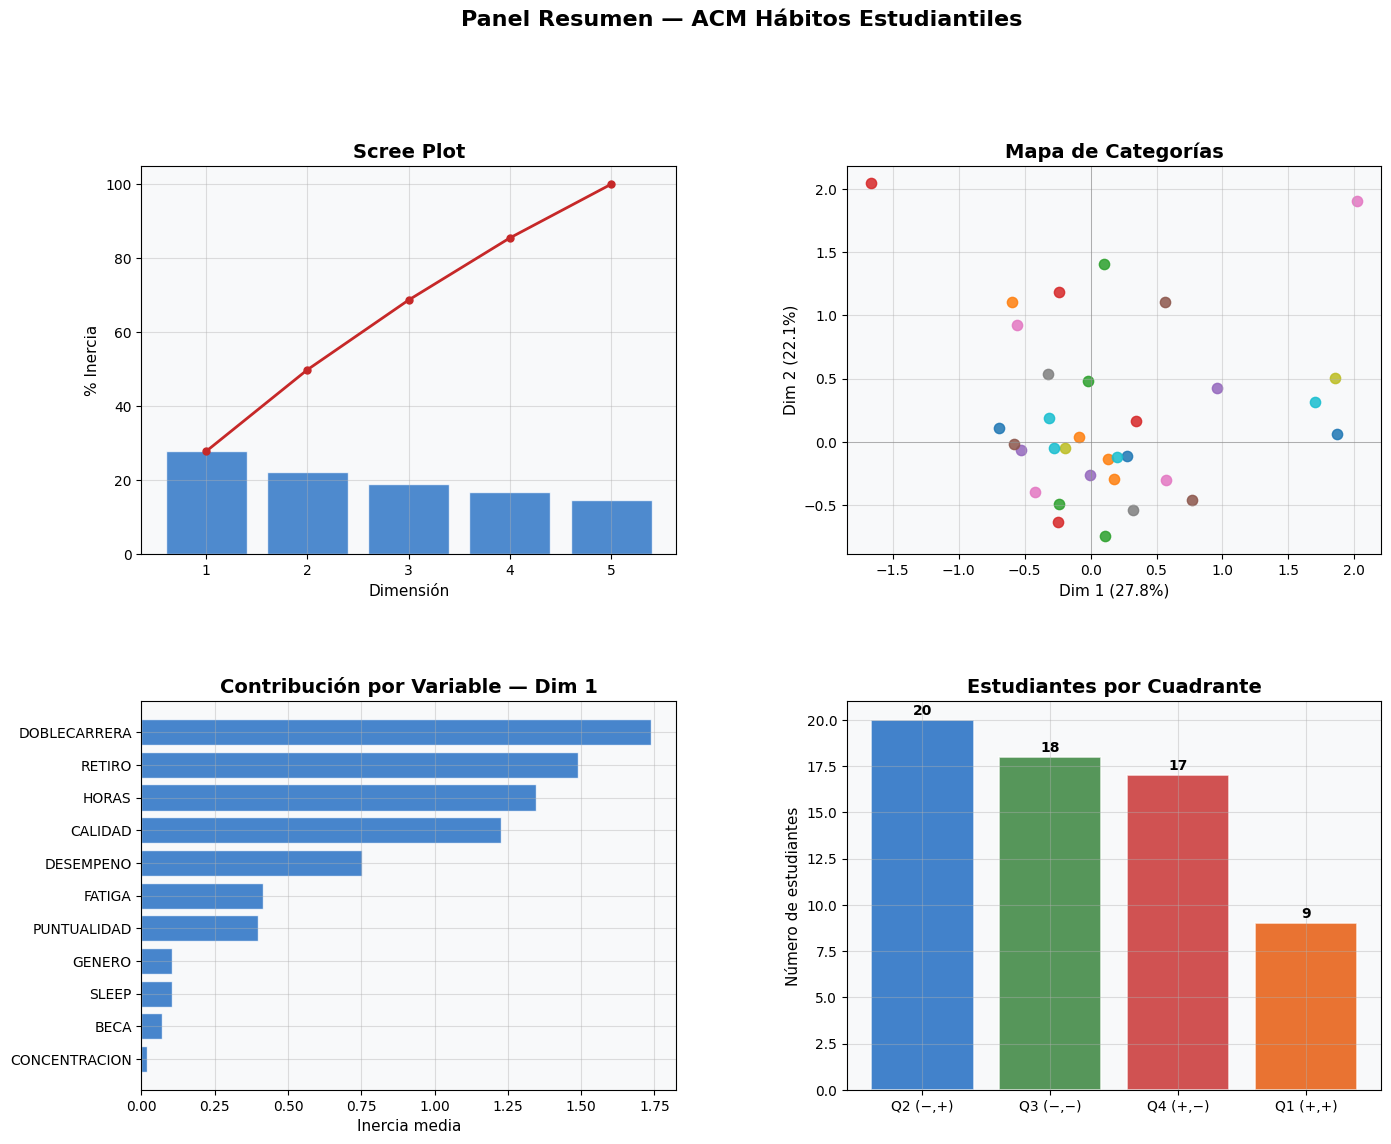


✅ Análisis de Correspondencia Múltiple completado exitosamente.


In [24]:
# ─── Panel resumen visual final ──────────────────────────────────────────────

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# Panel 1: Scree Plot
ax1 = fig.add_subplot(gs[0, 0])
n_d = min(10, len(mca.eigenvalues_))
dims_p = np.arange(1, n_d+1)
ev_p = mca.eigenvalues_[:n_d]
pct_p = 100 * ev_p / mca.eigenvalues_.sum()
ax1.bar(dims_p, pct_p, color='#1565C0', alpha=0.75, edgecolor='white')
ax1.plot(dims_p, np.cumsum(pct_p), 'o-', color='#C62828', linewidth=2, markersize=5)
ax1.set_title('Scree Plot', fontweight='bold')
ax1.set_xlabel('Dimensión')
ax1.set_ylabel('% Inercia')
ax1.set_xticks(dims_p)

# Panel 2: Mapa categorías (Dim1 vs Dim2)
ax2 = fig.add_subplot(gs[0, 1])
ax2.axhline(0, color='gray', lw=0.7, alpha=0.5)
ax2.axvline(0, color='gray', lw=0.7, alpha=0.5)
for var in variables_acm:
    sub = cat_coords[cat_coords['Variable'] == var]
    ax2.scatter(sub.iloc[:, 0], sub.iloc[:, 1],
                color=color_map2[var], s=55, alpha=0.85)
ax2.set_title('Mapa de Categorías', fontweight='bold')
ax2.set_xlabel(f'Dim 1 ({inercia_prince[0]:.1f}%)')
ax2.set_ylabel(f'Dim 2 ({inercia_prince[1]:.1f}%)')

# Panel 3: Contribución de variables Dim1
ax3 = fig.add_subplot(gs[1, 0])
vals1 = df_contrib['Dimensión 1'].sort_values()
ax3.barh(vals1.index, vals1.values, color='#1565C0', alpha=0.78, edgecolor='white')
ax3.set_title('Contribución por Variable — Dim 1', fontweight='bold')
ax3.set_xlabel('Inercia media')

# Panel 4: Distribución de estudiantes por cuadrante
ax4 = fig.add_subplot(gs[1, 1])
q_counts = ind_df['Cuadrante'].value_counts()
ax4.bar(q_counts.index, q_counts.values,
        color=['#1565C0', '#2E7D32', '#C62828', '#E65100'],
        alpha=0.8, edgecolor='white', linewidth=1.2)
ax4.set_title('Estudiantes por Cuadrante', fontweight='bold')
ax4.set_ylabel('Número de estudiantes')
for bar, val in zip(ax4.patches, q_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}', ha='center', fontweight='bold')

fig.suptitle('Panel Resumen — ACM Hábitos Estudiantiles',
             fontsize=16, fontweight='bold', y=1.01)
plt.show()

print("\n✅ Análisis de Correspondencia Múltiple completado exitosamente.")